In [49]:
import pandas as pd

df = pd.read_csv("cleaned_data")

In [50]:
df

,patid,index_date,scre,sbp,bmi,tc,hdlc,smoker,antihtn,diabetes,mi,stroke,hf,cvd,ascvd,date_of_birth,race,ethnicity,sex,age
0,1000174,2019-03-23 16:01:00,0.65,132.0,44.520000,161.0,38.0,0,0,0,0,0,0,0,0,1980-11-15,White,Not Hispanic or Latino,Female,38
1,1000196,2015-11-16 12:10:00,0.88,127.0,29.500000,211.0,47.0,0,0,0,0,0,0,0,0,1957-05-03,White,Not Hispanic or Latino,Male,58
2,1000207,2009-05-05 05:00:00,0.90,132.0,26.640000,198.0,52.0,0,0,0,0,0,0,0,0,1942-07-31,White,Not Hispanic or Latino,Female,66
3,1000536,2020-04-03 22:44:00,0.70,144.0,22.600000,185.0,41.0,0,0,0,0,0,0,0,0,1992-02-27,White,Not Hispanic or Latino,Female,28
4,1000678,2014-01-09 12:17:00,1.05,128.0,37.540001,237.0,51.0,0,0,1,1,0,1,1,1,1952-08-28,Black or African American,Not Hispanic or Latino,Female,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13478,9986016,2009-06-02 23:59:00,1.00,165.0,43.480000,176.0,59.0,0,0,0,0,0,1,1,0,1946-10-16,Black or African American,Not Hispanic or Latino,Female,62
13479,9987568,2023-01-06 12:01:00,1.13,107.0,44.700000,119.0,58.0,0,0,1,0,0,0,0,0,1960-06-12,Black or African American,Not Hispanic or Latino,Female,62
13480,9990186,2020-10-22 13:38:00,1.01,130.0,25.800000,224.0,46.0,0,0,0,0,0,0,0,0,1994-06-28,White,Not Hispanic or Latino,Male,26
13481,9990917,2010-01-18 12:27:00,0.65,130.0,24.540001,192.0,64.0,0,0,0,0,0,0,0,0,1966-07-02,White,Not Hispanic or Latino,Female,43


In [51]:
# Filter out patients who have never been diagnosed with CVD or ASCVD
df_cvd = df[(df["cvd"] == 1) | (df["ascvd"] == 1)].copy()
age_cutoff = 55  # can adjust this based on hypothesis

# Create early_late_cvd: 1 if diagnosed with CVD/ASCVD and age < cutoff
df_cvd.loc[:, "early_late_cvd"] = (df_cvd["age"] < age_cutoff).astype(
    int
)  # Convert to integer

In [5]:
df_cvd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1599 entries, 4 to 13478
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patid           1599 non-null   int64  
 1   index_date      1599 non-null   object 
 2   scre            1599 non-null   float64
 3   sbp             1599 non-null   float64
 4   bmi             1599 non-null   float64
 5   tc              1599 non-null   float64
 6   hdlc            1599 non-null   float64
 7   smoker          1599 non-null   int64  
 8   antihtn         1599 non-null   int64  
 9   diabetes        1599 non-null   int64  
 10  mi              1599 non-null   int64  
 11  stroke          1599 non-null   int64  
 12  hf              1599 non-null   int64  
 13  cvd             1599 non-null   int64  
 14  ascvd           1599 non-null   int64  
 15  date_of_birth   1599 non-null   object 
 16  race            1599 non-null   object 
 17  ethnicity       1599 non-null   objec

In [52]:
print(df_cvd["early_late_cvd"].value_counts())

early_late_cvd
0    966
1    633
Name: count, dtype: int64


In [7]:
df_cvd["race"].value_counts()

race
White                        992
Black or African American    573
Asian                         34
Name: count, dtype: int64

In [8]:
df_cvd["ethnicity"].value_counts()

ethnicity
Not Hispanic or Latino    1589
Hispanic or Latino          10
Name: count, dtype: int64

In [9]:
df_cvd["sex"].value_counts()

sex
Female    913
Male      686
Name: count, dtype: int64

In [10]:
# make sure there is no missing values
df_cvd.isna().sum()

patid             0
index_date        0
scre              0
sbp               0
bmi               0
tc                0
hdlc              0
smoker            0
antihtn           0
diabetes          0
mi                0
stroke            0
hf                0
cvd               0
ascvd             0
date_of_birth     0
race              0
ethnicity         0
sex               0
age               0
early_late_cvd    0
dtype: int64

In [54]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Define your feature set (X) and target variable (y)
# Remove 'age' from the feature set
X = df_cvd.drop(
    ["patid", "index_date", "date_of_birth", "cvd", "ascvd", "early_late_cvd", "age"],
    axis=1,
)
y = df_cvd["early_late_cvd"]  # Target variable

# Step 1: Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Split the training data further into 80% training and 20% validation (using y_train for stratification)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Print the sizes of the splits to verify
print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Validation Set Size: {X_val.shape[0]} samples")
print(f"Test Set Size: {X_test.shape[0]} samples")


# Identify categorical columns
categorical_columns = ["race", "ethnicity", "sex"]

Training Set Size: 1023 samples
Validation Set Size: 256 samples
Test Set Size: 320 samples


In [55]:
print(X.columns)

Index(['scre', 'sbp', 'bmi', 'tc', 'hdlc', 'smoker', 'antihtn', 'diabetes',
       'mi', 'stroke', 'hf', 'race', 'ethnicity', 'sex'],
      dtype='object')


In [56]:
# Scale numeric features
numeric_columns = X.select_dtypes(
    include=["float64", "int64"]
).columns  # Identify numeric columns
print(numeric_columns)

Index(['scre', 'sbp', 'bmi', 'tc', 'hdlc', 'smoker', 'antihtn', 'diabetes',
       'mi', 'stroke', 'hf'],
      dtype='object')


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Define the preprocessor with scaling
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(),
            categorical_columns,
        ),  # OneHot for categorical variables
        ("num", StandardScaler(), numeric_columns),  # Scale numeric features
    ],
    remainder="passthrough",  # Keep other columns unchanged
)

# Create the pipeline with scaling and logistic regression
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("logreg", LogisticRegression(max_iter=1000)),
    ]
)


# Fit the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Print predictions and accuracy
print("Predictions:", y_pred)
accuracy = pipeline.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Predictions: [0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0
 1 0 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 1 1
 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1
 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0
 1 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0
 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1]
Model Accuracy: 0.690625


In [60]:
from sklearn.metrics import (
    roc_auc_score,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
)

# Calculate the predicted probabilities for AUC
y_pred_prob = pipeline.predict_proba(X_test)[
    :, 1
]  # Probability of the positive class (class=1)

# Calculate AUC score
auc_LR = roc_auc_score(y_test, y_pred_prob)
print("AUC Score:", auc_LR)

AUC Score: 0.7188609195871242


In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Accuracy Scores: [0.671875   0.7        0.634375   0.653125   0.64890282]
Mean CV Accuracy: 0.6616555642633228


In [44]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)
print("Classification Report:", classification_report(y_test, y_pred))

Confusion Matrix: [[156  37]
 [ 65  62]]
Classification Report:               precision    recall  f1-score   support

           0       0.71      0.81      0.75       193
           1       0.63      0.49      0.55       127

    accuracy                           0.68       320
   macro avg       0.67      0.65      0.65       320
weighted avg       0.67      0.68      0.67       320



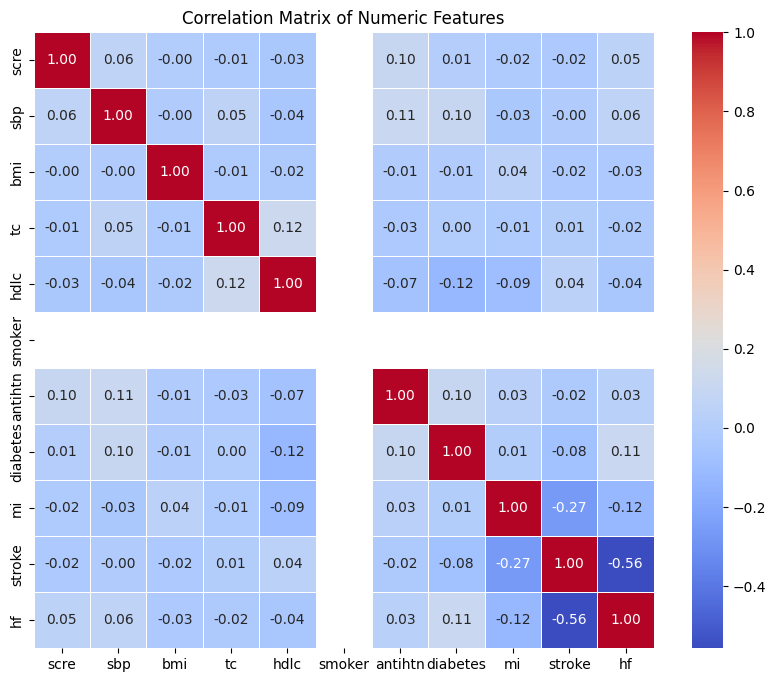

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = X[numeric_columns].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define categorical columns
categorical_columns = ["race", "ethnicity", "sex"]

# Define numeric columns
numeric_columns = X.select_dtypes(include=["float64", "int64"]).columns

# Create a column transformer to preprocess the data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(),
            categorical_columns,
        ),  # One-hot encode categorical columns
        ("num", StandardScaler(), numeric_columns),  # Standard scale numeric columns
    ]
)

# Create a pipeline that first applies preprocessing and then fits the Random Forest model
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("rf", RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42)),
    ]
)

# Fit the Random Forest model on the training data
rf_pipeline.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_pipeline.predict(X_test)

# Calculate accuracy on the test data
test_accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.6625


In [66]:
# Calculate the predicted probabilities for AUC
y_pred_prob = pipeline.predict_proba(X_test)[
    :, 1
]  # Probability of the positive class (class=1)

# Calculate AUC score
auc_RF = roc_auc_score(y_test, y_pred_prob)
print("AUC Score:", auc_RF)

AUC Score: 0.7385251163537152


Test Accuracy: 0.634
Test AUC: 0.656
Training Time: 0.1 seconds
Prediction Time: 0.01 seconds


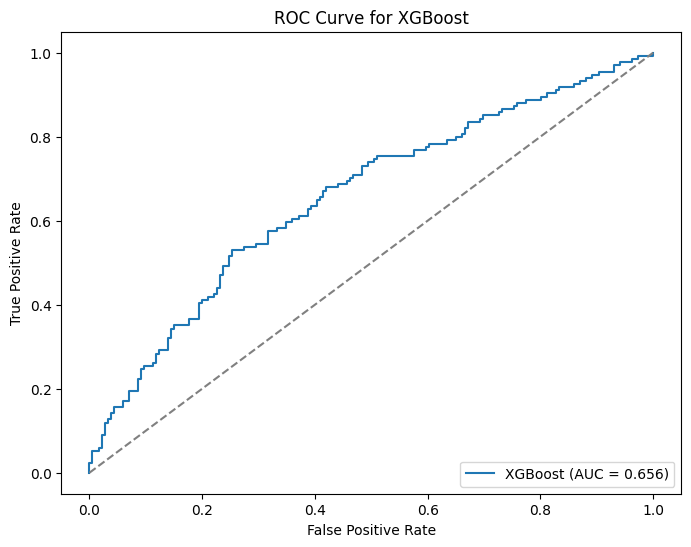

In [72]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np
import time

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define categorical columns
categorical_columns = ["race", "ethnicity", "sex"]

# Define numeric columns
numeric_columns = X.select_dtypes(include=["float64", "int64"]).columns

# Create a column transformer to preprocess the data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(),
            categorical_columns,
        ),  # One-hot encode categorical columns
        ("num", StandardScaler(), numeric_columns),  # Standard scale numeric columns
    ]
)

# Initialize the XGBoost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42)

# Create a pipeline that applies preprocessing and then fits the XGBoost model
xgb_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", xgb_model)])

# Train the XGBoost model on the training data
start_time = time.time()
xgb_pipeline.fit(X_train, y_train)
fit_time = round(time.time() - start_time, 2)  # Training time

# Make predictions on the test data
start_time = time.time()
y_pred = xgb_pipeline.predict(X_test)
y_pred_prob = xgb_pipeline.predict_proba(X_test)[
    :, 1
]  # Probability of the positive class
predict_time = round(time.time() - start_time, 2)  # Prediction time

# Calculate accuracy on the test data
test_accuracy_xgb = accuracy_score(y_test, y_pred)

# Calculate AUC on the test data
test_auc_xgb = roc_auc_score(y_test, y_pred_prob)

# Print the results
print(f"Test Accuracy: {test_accuracy_xgb:.3f}")
print(f"Test AUC: {test_auc_xgb:.3f}")
print(f"Training Time: {fit_time} seconds")
print(f"Prediction Time: {predict_time} seconds")

# Plot ROC Curve for XGBoost
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plotting ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot(
    [0, 1], [0, 1], color="gray", linestyle="--"
)  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost")
plt.legend(loc="lower right")
plt.show()

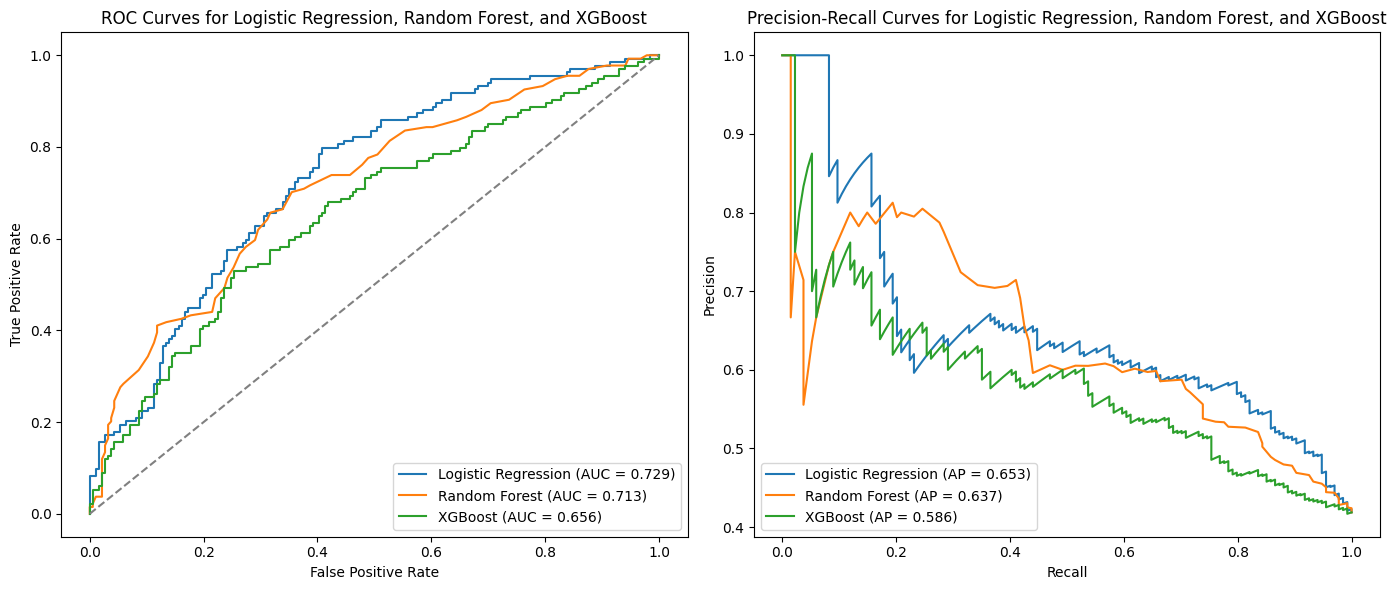

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np
import time

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define categorical columns
categorical_columns = ["race", "ethnicity", "sex"]

# Define numeric columns
numeric_columns = X.select_dtypes(include=["float64", "int64"]).columns

# Create a column transformer to preprocess the data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(),
            categorical_columns,
        ),  # One-hot encode categorical columns
        ("num", StandardScaler(), numeric_columns),  # Standard scale numeric columns
    ]
)

# Initialize models
LR_model = LogisticRegression(max_iter=1000, random_state=42)
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
XGB_model = XGBClassifier(random_state=42)

# Put models in a dictionary for easy iteration
models = {
    "Logistic Regression": LR_model,
    "Random Forest": RF_model,
    "XGBoost": XGB_model,
}

# Create a figure for plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train each model, compute predictions, and plot ROC curves and Precision-Recall curves
for model_name, model in models.items():
    # Create a pipeline for each model (preprocessing + model fitting)
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    # Start timer for training
    start_time = time.time()
    pipeline.fit(X_train, y_train)  # Fit the model
    fit_time = round(time.time() - start_time, 2)  # Training time

    # Start timer for predictions
    start_time = time.time()
    y_pred_prob = pipeline.predict_proba(X_test)[
        :, 1
    ]  # Get probability of the positive class
    predict_time = round(time.time() - start_time, 2)  # Prediction time

    # Compute AUC and ROC curve
    auc_score = roc_auc_score(y_test, y_pred_prob)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for each model on the first axis (axes[0])
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

    # Compute Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    avg_precision = average_precision_score(y_test, y_pred_prob)

    # Plot Precision-Recall curve for each model on the second axis (axes[1])
    axes[1].plot(recall, precision, label=f"{model_name} (AP = {avg_precision:.3f})")

# Customize the first plot (ROC Curve)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves for Logistic Regression, Random Forest, and XGBoost")
axes[0].plot(
    [0, 1], [0, 1], color="gray", linestyle="--"
)  # Diagonal line (random classifier)
axes[0].legend(loc="lower right")

# Customize the second plot (Precision-Recall Curve)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(
    "Precision-Recall Curves for Logistic Regression, Random Forest, and XGBoost"
)
axes[1].legend(loc="lower left")

# Show the plot
plt.tight_layout()
plt.show()

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define categorical columns
categorical_columns = ["race", "ethnicity", "sex"]

# Define numeric columns
numeric_columns = X.select_dtypes(include=["float64", "int64"]).columns

# Create a column transformer to preprocess the data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(),
            categorical_columns,
        ),  # One-hot encode categorical columns
        ("num", StandardScaler(), numeric_columns),  # Standard scale numeric columns
    ]
)

# Initialize models
LR_model = LogisticRegression(max_iter=1000, random_state=42)
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
XGB_model = XGBClassifier(random_state=42)

# Put models in a dictionary for easy iteration
models = {
    "Logistic Regression": LR_model,
    "Random Forest": RF_model,
    "XGBoost": XGB_model,
}

# Store results for AUC, training time, and prediction time
results = {
    "Model": [],
    "Training AUC": [],
    "Test AUC": [],
    "Training Time": [],
    "Prediction Time": [],
}

# Train each model, compute AUC, training time, and prediction time
for model_name, model in models.items():
    # Create a pipeline for each model (preprocessing + model fitting)
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    # Start timer for training
    start_time = time.time()
    pipeline.fit(X_train, y_train)  # Fit the model
    fit_time = round(time.time() - start_time, 2)  # Training time

    # Start timer for predictions
    start_time = time.time()
    y_pred_prob = pipeline.predict_proba(X_test)[
        :, 1
    ]  # Get probability of the positive class
    predict_time = round(time.time() - start_time, 2)  # Prediction time

    # Compute AUC for training and test sets
    auc_train = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, y_pred_prob)

    # Store results in the dictionary
    results["Model"].append(model_name)
    results["Training AUC"].append(auc_train)
    results["Test AUC"].append(auc_test)
    results["Training Time"].append(fit_time)
    results["Prediction Time"].append(predict_time)

# Convert results to a pandas DataFrame for easier handling
results_table = pd.DataFrame(results)

# Print results table
print(results_table)

                 Model  Training AUC  Test AUC  Training Time  Prediction Time
0  Logistic Regression      0.686527  0.729498           0.02             0.01
1        Random Forest      1.000000  0.713108           0.35             0.02
2              XGBoost      1.000000  0.656436           0.09             0.01


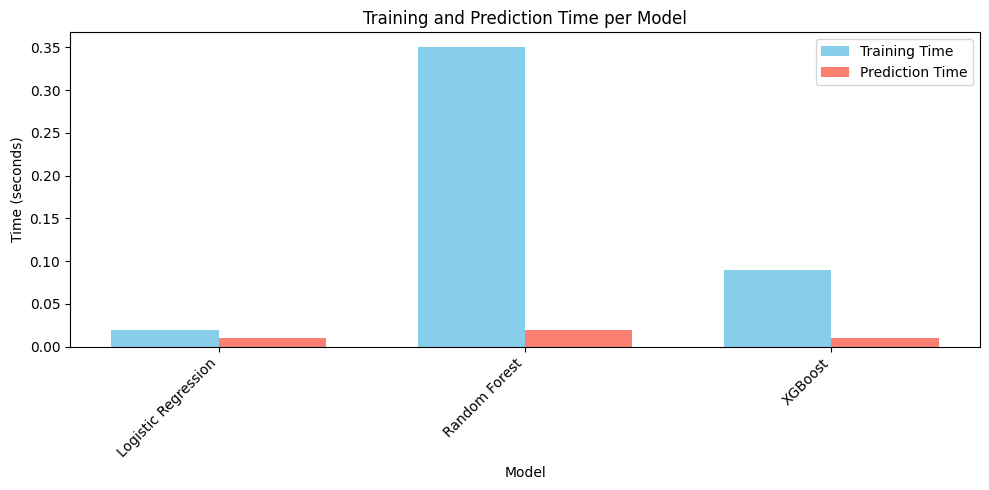

In [75]:
# Plotting the bar chart for Training and Prediction Time
fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.35
x = range(len(results_table))

# Plot training time
ax.bar(
    x,
    results_table["Training Time"],
    width=bar_width,
    label="Training Time",
    color="skyblue",
)

# Plot prediction time
ax.bar(
    [i + bar_width for i in x],
    results_table["Prediction Time"],
    width=bar_width,
    label="Prediction Time",
    color="salmon",
)

# Customize the plot
ax.set_xlabel("Model")
ax.set_ylabel("Time (seconds)")
ax.set_title("Training and Prediction Time per Model")
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(results_table["Model"], rotation=45, ha="right")
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [77]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define categorical columns
categorical_columns = ["race", "ethnicity", "sex"]

# Define numeric columns
numeric_columns = X.select_dtypes(include=["float64", "int64"]).columns

# Create a column transformer to preprocess the data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent"),
                    ),  # Handle missing categorical values
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore"),
                    ),  # One-hot encode categorical columns
                ]
            ),
            categorical_columns,
        ),
        (
            "num",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(strategy="mean"),
                    ),  # Handle missing numerical values
                    ("scaler", StandardScaler()),  # Standard scale numeric columns
                ]
            ),
            numeric_columns,
        ),
    ]
)

# Initialize models
RF_model = RandomForestClassifier(random_state=42)
XGB_model = XGBClassifier(random_state=42)

# Define parameter grid for Random Forest
rf_param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["auto", "sqrt", "log2"],
    "model__bootstrap": [True, False],
}

# Set up RandomizedSearchCV for Random Forest
rf_random_search = RandomizedSearchCV(
    estimator=Pipeline([("preprocessor", preprocessor), ("model", RF_model)]),
    param_distributions=rf_param_grid,
    n_iter=10,  # Number of random combinations to try
    cv=5,  # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

# Fit RandomizedSearchCV for Random Forest
rf_random_search.fit(X_train, y_train)

best_params_rf = rf_random_search.best_params_

# Best parameters for Random Forest
print(f"Best parameters for Random Forest: {best_params_rf}")

# Best model for Random Forest
best_rf_model = rf_random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.0s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; 

/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.10/site-packages/sklearn/base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/conda/lib/python3.10/site-packages/sklearn/pipeline.py", line 420, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/opt/conda/lib/python3.1

Best parameters for Random Forest: {'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__bootstrap': True}


In [80]:
y_val_rf = best_rf_model.predict_proba(X_val)[:, 1]
auc_rf = roc_auc_score(y_val, y_val_rf)

print("Best parameters for Random Forest:")
print(rf_random_search.best_params_)
print("Validation AUC:", auc_rf)

Best parameters for Random Forest:
{'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__bootstrap': True}
Validation AUC: 0.9168316831683169
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_lea

In [81]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for XGBoost
xgb_param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    "model__n_estimators": [50, 100, 150, 200],  # Number of boosting rounds
    "model__max_depth": [3, 6, 10],  # Maximum depth of a tree
    "model__subsample": [
        0.6,
        0.8,
        1.0,
    ],  # Fraction of samples used in each boosting round
    "model__colsample_bytree": [
        0.6,
        0.8,
        1.0,
    ],  # Fraction of features used in each boosting round
    "model__gamma": [
        0,
        0.1,
        0.2,
        0.3,
    ],  # Minimum loss reduction required to make a further partition
}

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Set up RandomizedSearchCV for XGBoost
xgb_random_search = RandomizedSearchCV(
    estimator=Pipeline([("preprocessor", preprocessor), ("model", xgb_model)]),
    param_distributions=xgb_param_grid,
    n_iter=100,  # Number of random combinations to try
    cv=5,  # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1,  # Use all cores to speed up the search
)

# Fit RandomizedSearchCV for XGBoost
xgb_random_search.fit(X_train, y_train)

best_params_xgb = xgb_random_search.best_params_

# Best parameters for XGBoost
print(f"Best parameters for XGBoost: {best_params_xgb}")

# Best model for XGBoost
best_xgb_model = xgb_random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=50, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=50, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.2, model__max_depth=3, model__n_estimators=100, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.2, model__max_depth=3, model__n_estimators=100, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0.2, model__learning_rate=0.05, model__max_depth=10, mo

In [84]:
y_val_xgb = best_xgb_model.predict_proba(X_val)[:, 1]
auc_xgb = roc_auc_score(y_val, y_val_xgb)

print("Best parameters for XGBoost:")
print(xgb_random_search.best_params_)
print("Validation AUC:", auc_xgb)

Best parameters for XGBoost:
{'model__subsample': 0.6, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.2, 'model__colsample_bytree': 0.6}
Validation AUC: 0.7785372085595658


In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the parameter grid for Logistic Regression
lr_param_grid = {
    "model__penalty": ["l1", "l2", "elasticnet"],  # Regularization type
    "model__C": np.logspace(-4, 4, 20),  # Regularization strength
    "model__solver": ["liblinear", "saga"],  # Solver
    "model__max_iter": [100, 200, 300],  # Maximum iterations for optimization
    "model__class_weight": [None, "balanced"],  # Handle class imbalance
}

# Initialize the Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Set up RandomizedSearchCV for Logistic Regression
lr_random_search = RandomizedSearchCV(
    estimator=Pipeline([("preprocessor", preprocessor), ("model", lr_model)]),
    param_distributions=lr_param_grid,
    n_iter=100,  # Number of random combinations to try
    cv=5,  # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1,  # Use all cores to speed up the search
)

# Fit RandomizedSearchCV for Logistic Regression
lr_random_search.fit(X_train, y_train)

best_params_lr = lr_random_search.best_params_

# Best parameters for Logistic Regression
print(f"Best parameters for Logistic Regression: {best_params_lr}")

# Best model for Logistic Regression
best_lr_model = lr_random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

[CV] END model__colsample_bytree=1.0, model__gamma=0.2, model__learning_rate=0.2, model__max_depth=6, model__n_estimators=50, model__subsample=1.0; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__subsample=0.6; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=0.6, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=50, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=100, model__subsample=1.0; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=6, model__n_estimators=150, model__subsample=0.6; total time=   0

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

[CV] END model__colsample_bytree=0.6, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=50, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=100, model__subsample=1.0; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=6, model__n_estimators=150, model__subsample=0.6; total time=   0.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.2, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0.2, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=0.6, model__gamma=0.2, model__learning_rate=0.2, model__max_depth=3, model__n_estimators=50, model__subsample=1.0; total time=   0.

...

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__subsample=0.6; total time=   0.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=100, model__subsample=1.0; total time=   0.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__subsample=0.6; total time=   0.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__gamma=0.2, model__learning_rate=0.05, model__max_depth=6, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0.3, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=50, model__subsample=1.0; total time=  

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

Best parameters for Logistic Regression: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__max_iter': 300, 'model__class_weight': None, 'model__C': 0.615848211066026}


/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
155 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.10/site-packages/sklearn/base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/conda/lib/python3.10/site-packages/sklearn/pipeline.py", line 420, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/opt/conda/lib/pytho

In [89]:
y_val_lr = best_lr_model.predict_proba(X_val)[:, 1]
auc_lr = roc_auc_score(y_val, y_val_lr)

print("Best parameters for Logistic Regression:")
print(lr_random_search.best_params_)
print("Validation AUC:", auc_lr)

Best parameters for Logistic Regression:
{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__max_iter': 300, 'model__class_weight': None, 'model__C': 0.615848211066026}
Validation AUC: 0.7033535611625679


In [87]:
best_params_rf = rf_random_search.best_params_
best_params_xgb = xgb_random_search.best_params_
best_params_lr = lr_random_search.best_params_

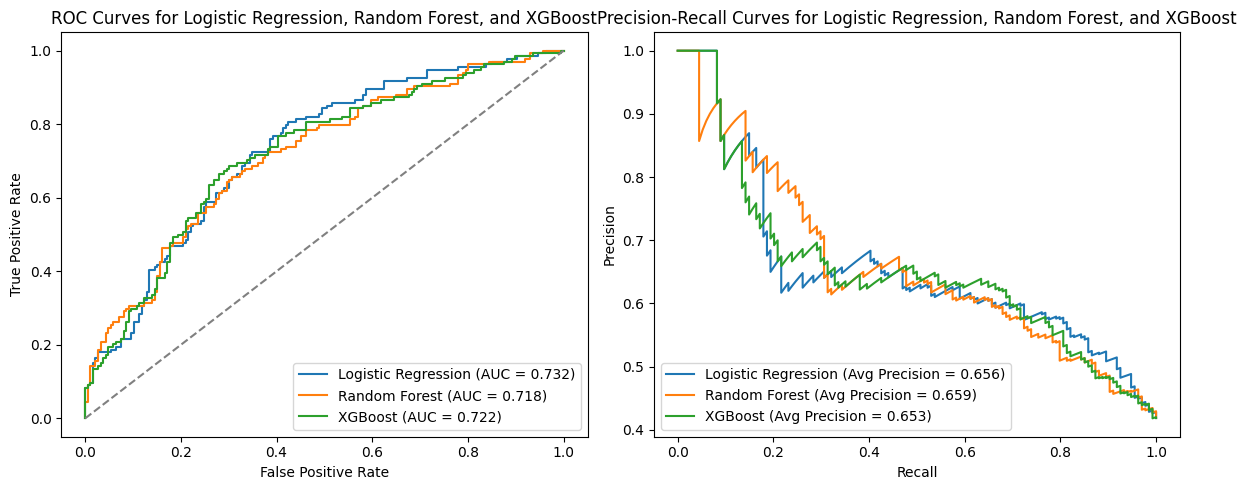

In [91]:
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (
    roc_auc_score,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
)
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Initialize Logistic Regression with best parameters from best_params_lr
LR_model = LogisticRegression(
    solver="liblinear",  # best_params_lr["solver"]
    penalty="l1",  # best_params_lr["penalty"]
    C=0.615848211066026,  # best_params_lr["C"]
    max_iter=300,  # best_params_lr["max_iter"]
    class_weight=None,  # best_params_lr["class_weight"]
)

# Initialize Random Forest with best parameters from best_params_rf
RF_model = RandomForestClassifier(
    n_estimators=150,  # best_params_rf["n_estimators"]
    min_samples_split=5,  # best_params_rf["min_samples_split"]
    min_samples_leaf=2,  # best_params_rf["min_samples_leaf"]
    max_features="log2",  # best_params_rf["max_features"]
    max_depth=10,  # best_params_rf["max_depth"]
    bootstrap=True,  # best_params_rf["bootstrap"]
)

# Initialize XGBoost with best parameters from best_params_xgb
XGB_model = xgb.XGBClassifier(
    subsample=0.6,  # best_params_xgb["subsample"]
    n_estimators=200,  # best_params_xgb["n_estimators"]
    max_depth=3,  # best_params_xgb["max_depth"]
    learning_rate=0.01,  # best_params_xgb["learning_rate"]
    gamma=0.2,  # best_params_xgb["gamma"]
    colsample_bytree=0.6,  # best_params_xgb["colsample_bytree"]
    eval_metric="auc",  # Use AUC as evaluation metric
    random_state=42,
)

# Place all models in a dictionary for easy iteration
models = {
    "Logistic Regression": LR_model,
    "Random Forest": RF_model,
    "XGBoost": XGB_model,
}

results = {
    "Model": [],
    "Training AUC": [],
    "Test AUC": [],
    "Training Time": [],
    "Prediction Time": [],
}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Train each model, compute predictions, and plot ROC and Precision-Recall curves
for model_name, model in models.items():
    # Create a pipeline for each model (preprocessing + model fitting)
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    # Start timer for training
    start_time = time.time()
    pipeline.fit(X_train, y_train)  # Fit the model
    fit_time = round(time.time() - start_time, 2)  # Training time

    # Start timer for predictions
    start_time = time.time()
    y_pred_prob = pipeline.predict_proba(X_test)[
        :, 1
    ]  # Get probability of the positive class
    predict_time = round(time.time() - start_time, 2)  # Prediction time

    # Compute AUC for training and test sets
    auc_train = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, y_pred_prob)

    # Store results in the dictionary
    results["Model"].append(model_name)
    results["Training AUC"].append(auc_train)
    results["Test AUC"].append(auc_test)
    results["Training Time"].append(fit_time)
    results["Prediction Time"].append(predict_time)

    # Plot ROC curve on the first axis (axes[0])
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

    # Plot Precision-Recall curve on the second axis (axes[1])
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    avg_precision = average_precision_score(y_test, y_pred_prob)
    axes[1].plot(
        recall,
        precision,
        label=f"{model_name} (Avg Precision = {avg_precision:.3f})",
    )

# Customize the first plot (ROC curve)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves for Logistic Regression, Random Forest, and XGBoost")
axes[0].plot(
    [0, 1], [0, 1], color="gray", linestyle="--"
)  # Diagonal line (random classifier)
axes[0].legend(loc="lower right")

# Customize the second plot (Precision-Recall curve)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(
    "Precision-Recall Curves for Logistic Regression, Random Forest, and XGBoost"
)
axes[1].legend(loc="lower left")

# Show the plot
plt.tight_layout()
plt.show()

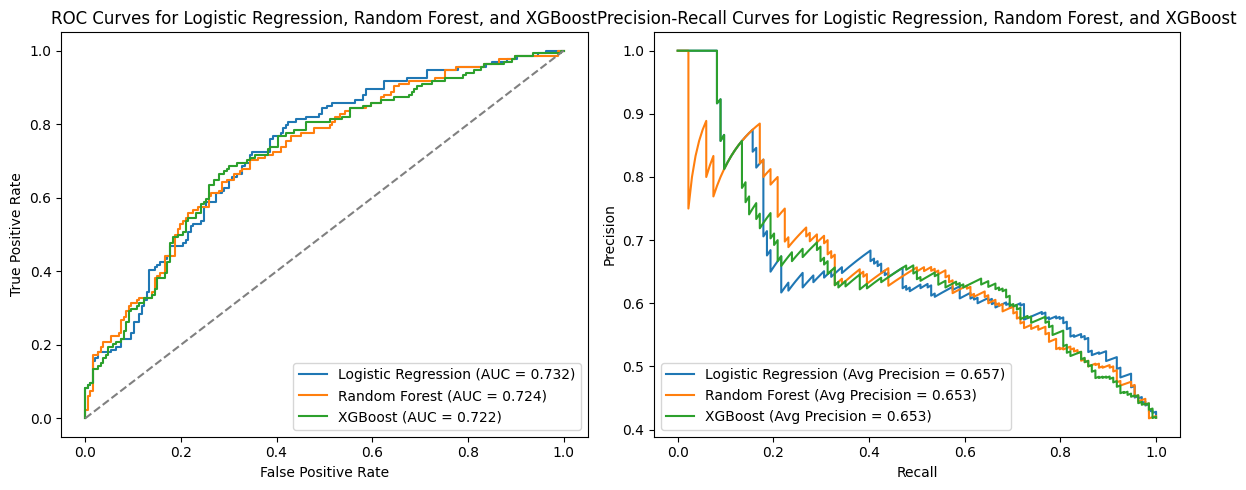

                 Model  Training AUC  Test AUC  Training Time  \
0  Logistic Regression      0.686666  0.731624           0.02   
1        Random Forest      0.963319  0.724362           0.44   
2              XGBoost      0.770605  0.722276           0.09   

   Prediction Time  Test Accuracy  
0             0.01       0.668750  
1             0.04       0.656250  
2             0.01       0.646875  


In [93]:
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (
    roc_auc_score,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    accuracy_score,
)
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Initialize Logistic Regression with best parameters from best_params_lr
# Initialize Logistic Regression with best parameters from best_params_lr
LR_model = LogisticRegression(
    solver="liblinear",  # best_params_lr["solver"]
    penalty="l1",  # best_params_lr["penalty"]
    C=0.615848211066026,  # best_params_lr["C"]
    max_iter=300,  # best_params_lr["max_iter"]
    class_weight=None,  # best_params_lr["class_weight"]
)

# Initialize Random Forest with best parameters from best_params_rf
RF_model = RandomForestClassifier(
    n_estimators=150,  # best_params_rf["n_estimators"]
    min_samples_split=5,  # best_params_rf["min_samples_split"]
    min_samples_leaf=2,  # best_params_rf["min_samples_leaf"]
    max_features="log2",  # best_params_rf["max_features"]
    max_depth=10,  # best_params_rf["max_depth"]
    bootstrap=True,  # best_params_rf["bootstrap"]
)

# Initialize XGBoost with best parameters from best_params_xgb
XGB_model = xgb.XGBClassifier(
    subsample=0.6,  # best_params_xgb["subsample"]
    n_estimators=200,  # best_params_xgb["n_estimators"]
    max_depth=3,  # best_params_xgb["max_depth"]
    learning_rate=0.01,  # best_params_xgb["learning_rate"]
    gamma=0.2,  # best_params_xgb["gamma"]
    colsample_bytree=0.6,  # best_params_xgb["colsample_bytree"]
    eval_metric="auc",  # Use AUC as evaluation metric
    random_state=42,
)

# Place all models in a dictionary for easy iteration
models = {
    "Logistic Regression": LR_model,
    "Random Forest": RF_model,
    "XGBoost": XGB_model,
}

results = {
    "Model": [],
    "Training AUC": [],
    "Test AUC": [],
    "Training Time": [],
    "Prediction Time": [],
    "Test Accuracy": [],  # Added a new field to store test accuracy
}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Train each model, compute predictions, and plot ROC and Precision-Recall curves
for model_name, model in models.items():
    # Create a pipeline for each model (preprocessing + model fitting)
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    # Start timer for training
    start_time = time.time()
    pipeline.fit(X_train, y_train)  # Fit the model
    fit_time = round(time.time() - start_time, 2)  # Training time

    # Start timer for predictions
    start_time = time.time()
    y_pred_prob = pipeline.predict_proba(X_test)[
        :, 1
    ]  # Get probability of the positive class
    y_pred = pipeline.predict(X_test)  # Get the predicted classes (0 or 1)
    predict_time = round(time.time() - start_time, 2)  # Prediction time

    # Compute AUC for training and test sets
    auc_train = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, y_pred_prob)

    # Compute Test Accuracy
    test_accuracy = accuracy_score(y_test, y_pred)  # Test accuracy

    # Store results in the dictionary
    results["Model"].append(model_name)
    results["Training AUC"].append(auc_train)
    results["Test AUC"].append(auc_test)
    results["Training Time"].append(fit_time)
    results["Prediction Time"].append(predict_time)
    results["Test Accuracy"].append(test_accuracy)  # Store test accuracy

    # Plot ROC curve on the first axis (axes[0])
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

    # Plot Precision-Recall curve on the second axis (axes[1])
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    avg_precision = average_precision_score(y_test, y_pred_prob)
    axes[1].plot(
        recall,
        precision,
        label=f"{model_name} (Avg Precision = {avg_precision:.3f})",
    )

# Customize the first plot (ROC curve)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves for Logistic Regression, Random Forest, and XGBoost")
axes[0].plot(
    [0, 1], [0, 1], color="gray", linestyle="--"
)  # Diagonal line (random classifier)
axes[0].legend(loc="lower right")

# Customize the second plot (Precision-Recall curve)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(
    "Precision-Recall Curves for Logistic Regression, Random Forest, and XGBoost"
)
axes[1].legend(loc="lower left")

# Show the plot
plt.tight_layout()
plt.show()

# Print out the results table for all models
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)

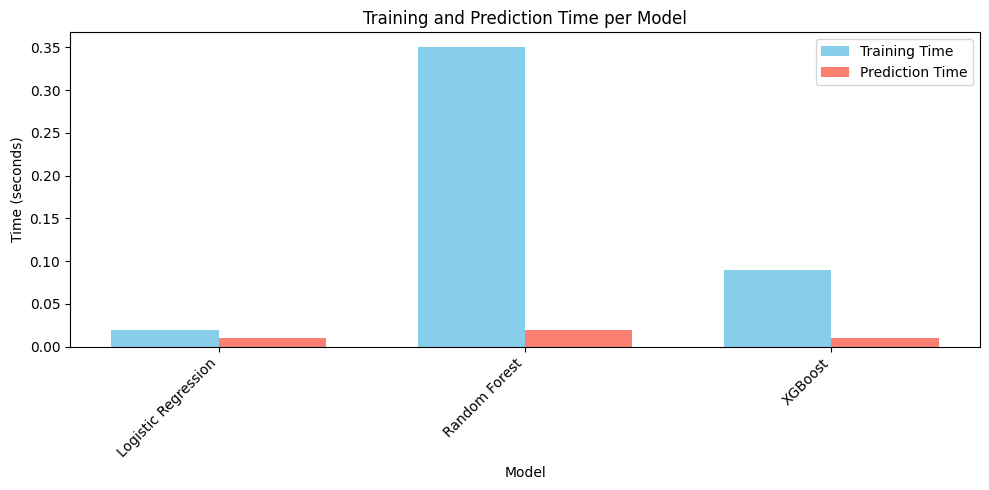

In [96]:
# Plotting the bar chart for Training and Prediction Time
fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.35
x = range(len(results_table))

# Plot training time
ax.bar(
    x,
    results_table["Training Time"],
    width=bar_width,
    label="Training Time",
    color="skyblue",
)

# Plot prediction time
ax.bar(
    [i + bar_width for i in x],
    results_table["Prediction Time"],
    width=bar_width,
    label="Prediction Time",
    color="salmon",
)

# Customize the plot
ax.set_xlabel("Model")
ax.set_ylabel("Time (seconds)")
ax.set_title("Training and Prediction Time per Model")
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(results_table["Model"], rotation=45, ha="right")
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [95]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score

# Create a column transformer to preprocess the data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(),
            categorical_columns,
        ),  # One-hot encode categorical columns
        ("num", StandardScaler(), numeric_columns),  # Standard scale numeric columns
    ]
)

# Initialize the base models (Logistic Regression, Random Forest, XGBoost)
base_models = [
    (
        "lr",
        Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor,
                ),  # Preprocessing step for logistic regression
                (
                    "model",
                    LogisticRegression(
                        solver="liblinear",
                        penalty="l1",
                        C=0.615848211066026,
                        max_iter=300,
                        class_weight=None,
                    ),
                ),
            ]
        ),
    ),
    (
        "rf",
        Pipeline(
            steps=[
                ("preprocessor", preprocessor),  # Preprocessing step for random forest
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=150,
                        min_samples_split=5,
                        min_samples_leaf=2,
                        max_features="log2",
                        max_depth=10,
                        bootstrap=True,
                    ),
                ),
            ]
        ),
    ),
    (
        "xgb",
        Pipeline(
            steps=[
                ("preprocessor", preprocessor),  # Preprocessing step for XGBoost
                (
                    "model",
                    XGBClassifier(
                        subsample=0.6,
                        n_estimators=200,
                        max_depth=3,
                        learning_rate=0.01,
                        gamma=0.2,
                        colsample_bytree=0.6,
                        eval_metric="auc",
                        random_state=42,
                    ),
                ),
            ]
        ),
    ),
]

# Initialize the meta-model (Logistic Regression for simplicity)
meta_model = LogisticRegression(solver="liblinear")

# Create the StackingClassifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Evaluate the stacking model on the test set
y_pred_prob = stacking_model.predict_proba(X_test)[:, 1]
auc_test_stacked = roc_auc_score(y_test, y_pred_prob)
test_accuracy_stacked = accuracy_score(y_test, stacking_model.predict(X_test))

print(f"Test AUC of Stacked Model: {auc_test_stacked:.4f}")
print(f"Test Accuracy of Stacked Model: {test_accuracy_stacked:.4f}")

Test AUC of Stacked Model: 0.7374
Test Accuracy of Stacked Model: 0.6469
